<a href="https://colab.research.google.com/github/natsakh/ElectromagneticNets/blob/main/TimeVaryingMedia/Analytics/InitialValueProblems/01_time_jump_E_H.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Abrupt Temporal Transition — Electric Field

## Problem formulation

We consider a plane electromagnetic wave propagating in a homogeneous, nondispersive medium. At \(t=0\), the refractive index changes instantaneously,

$$
n_1 \rightarrow n_2.
$$

The aim is to determine the temporal evolution of the electric field after the transition.

## Incident field

Before the temporal transition, the incident electric field is

$$
\mathbf{e}_0(z,t)
=
E_0 e^{i\omega_1 t} e^{-ik_1 z}\,\mathbf{x},
$$

where

$$
k_1=\frac{n_1\omega_1}{c}.
$$

In this notebook, only the temporal dependence is considered. Equivalently, the field is evaluated at \(z=0\), and the common spatial factor $$e^{-ik_1z}$$ is omitted:

$$
e_0(t)=E_0e^{i\omega_1t}.
$$

## Wave equation after the time jump

For \(t>0\), the refractive index is constant and equal to \(n_2\). The electric field satisfies

$$
\frac{\partial^2\mathbf{e}(z,t)}{\partial z^2}
-
\frac{n_2^2}{c^2}
\frac{\partial^2\mathbf{e}(z,t)}{\partial t^2}
=
0.
$$

## Initial conditions

At a temporal interface, the electric displacement

$$
\mathbf{d}=\varepsilon_0 n^2\mathbf{e}
$$

and its first time derivative are continuous.

Therefore, the electric field immediately after the jump satisfies

$$
\mathbf{e}(z,+0)
=
\frac{n_1^2}{n_2^2}\mathbf{e}_0(z,-0),
$$

and

$$
\left.
\frac{\partial\mathbf{e}(z,t)}{\partial t}
\right|_{t=+0}
=
\frac{n_1^2}{n_2^2}
\left.
\frac{\partial\mathbf{e}_0(z,t)}{\partial t}
\right|_{t=-0}.
$$

## Analytical solution

The spatial wavenumber is conserved at the temporal interface. Hence, the frequency after the transition is

$$
\omega_2=\frac{n_1}{n_2}\omega_1.
$$

For \(t>0\), the electric field is represented as a superposition of time-transmitted and time-reflected waves,

$$
e(t)
=
C_{\mathrm{T}}e^{i\omega_2t}
+
C_{\mathrm{R}}e^{-i\omega_2t}.
$$

The corresponding amplitudes are

$$
C_{\mathrm{T}}
=
E_0\frac{n_1(n_1+n_2)}{2n_2^2},
$$

$$
C_{\mathrm{R}}
=
E_0\frac{n_1(n_1-n_2)}{2n_2^2}.
$$

Thus, the final electric-field solution is

$$
e(t)
=
E_0\frac{n_1}{2n_2}
\left[
\frac{n_1+n_2}{n_2}e^{i\omega_2t}
+
\frac{n_1-n_2}{n_2}e^{-i\omega_2t}
\right],
\qquad t>0.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Python implementation

In [2]:
def time_jump_analytics(t, n1, n2, w1, E0=1.0):

    w2 = n1 / n2 * w1

    C_T = E0 * n1 * (n1 + n2) / (2 * n2**2)
    C_R = E0 * n1 * (n1 - n2) / (2 * n2**2)

    e = (
        C_T * np.exp(1j * w2 * t)
        + C_R * np.exp(-1j * w2 * t)
    )

    return e, C_T, C_R

## Example

The reference period is defined by

$$
T_{\mathrm{ref}}=\frac{2\pi}{\omega_1}.
$$

Time is displayed in the normalized form $t/T_{\mathrm{ref}}$.

In [3]:
n1 = 1.5
n2 = 1.0
w1 = 2 * np.pi
E0 = 1.0

T_ref = 2 * np.pi / w1

t = np.linspace(-2 * T_ref, 5 * T_ref, 2000)

t_before = t[t < 0]
t_after = t[t >= 0]

e_incident = E0 * np.exp(1j * w1 * t_before)

e_after, C_T, C_R = time_jump_analytics(
    t_after, n1, n2, w1, E0
)

w2 = n1 / n2 * w1

print(f"w2  = {w2:.6f}")
print(f"C_T = {C_T:.6f}")
print(f"C_R = {C_R:.6f}")

w2  = 9.424778
C_T = 1.875000
C_R = 0.375000


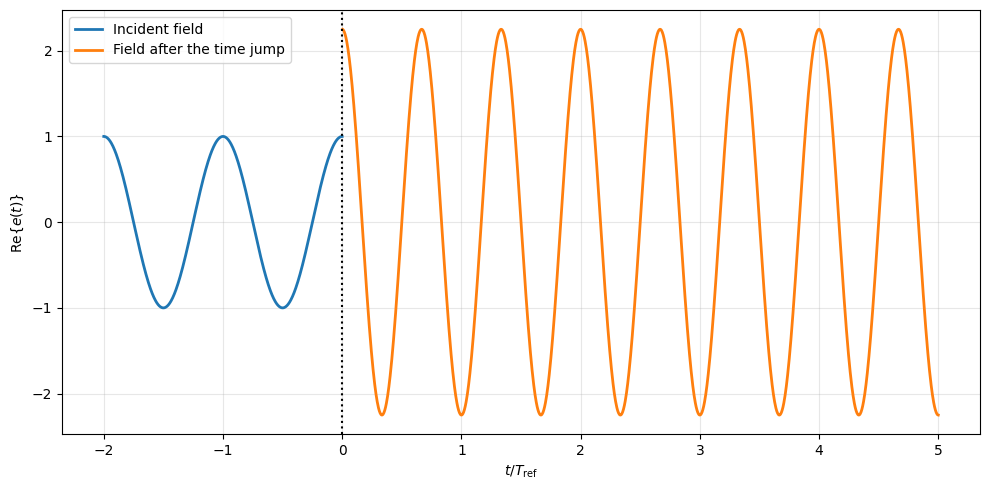

In [4]:
plt.figure(figsize=(10, 5))

plt.plot(
    t_before / T_ref,
    np.real(e_incident),
    lw=2,
    label="Incident field"
)

plt.plot(
    t_after / T_ref,
    np.real(e_after),
    lw=2,
    label="Field after the time jump"
)

plt.axvline(0, color="black", ls=":", lw=1.5)

plt.xlabel(r"$t/T_{\mathrm{ref}}$")
plt.ylabel(r"$\mathrm{Re}\{e(t)\}$")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Magnetic field

Once the electric field is known, the corresponding magnetic field can be recovered from Faraday's law,

$$
\nabla\times\mathbf{e}(z,t)
=
-\mu_0\frac{\partial\mathbf{h}(z,t)}{\partial t}.
$$

For the plane wave

$$
\mathbf{e}(z,t)
=
\left(
C_{\mathrm{T}}e^{i\omega_2t}
+
C_{\mathrm{R}}e^{-i\omega_2t}
\right)
e^{-ik_1z}\,\mathbf{x},
$$

the magnetic field is

$$
\mathbf{h}(z,t)
=
\frac{1}{Z_2}
\left(
C_{\mathrm{T}}e^{i\omega_2t}
-
C_{\mathrm{R}}e^{-i\omega_2t}
\right)
e^{-ik_1z}\,\mathbf{y},
\qquad t>0,
$$

where

$$
Z_2=\frac{Z_0}{n_2},
\qquad
Z_0=\mu_0c.
$$

Therefore,

$$
\mathbf{h}(z,t)
=
\frac{E_0}{Z_2}\frac{n_1}{2n_2}
\left[
\frac{n_1+n_2}{n_2}e^{i\omega_2t}
-
\frac{n_1-n_2}{n_2}e^{-i\omega_2t}
\right]
e^{-ik_1z}\,\mathbf{y},
\qquad t>0.
$$

Before the temporal transition, the incident magnetic field is

$$
\mathbf{h}_0(z,t)
=
\frac{E_0}{Z_1}
e^{i\omega_1t}
e^{-ik_1z}\,\mathbf{y},
$$

where

$$
Z_1=\frac{Z_0}{n_1}.
$$

As for the electric field, the common spatial factor is omitted in the numerical implementation below.


In [5]:
# Vacuum impedance
Z0 = 376.730313668

Z1 = Z0 / n1
Z2 = Z0 / n2

h_incident = E0 / Z1 * np.exp(1j * w1 * t_before)

h_after = (
    C_T * np.exp(1j * w2 * t_after)
    - C_R * np.exp(-1j * w2 * t_after)
) / Z2


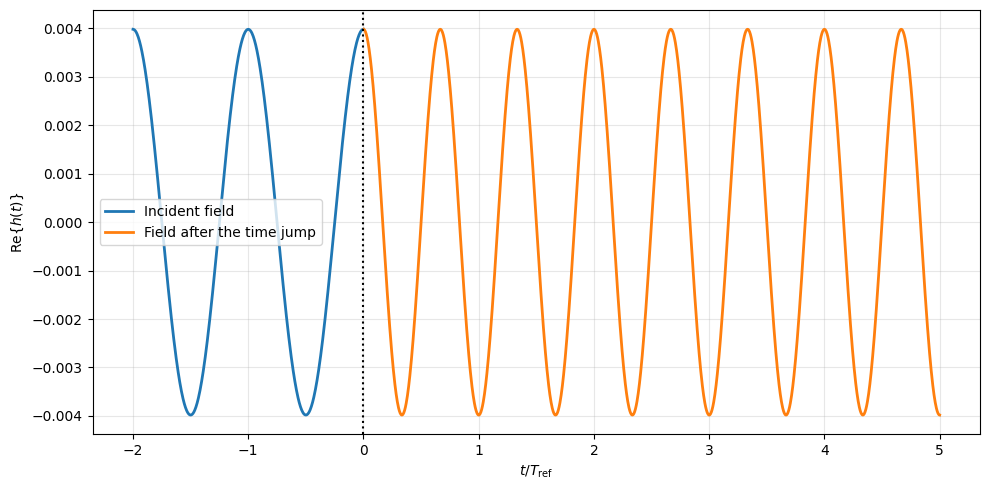

In [6]:
plt.figure(figsize=(10, 5))

plt.plot(
    t_before / T_ref,
    np.real(h_incident),
    lw=2,
    label="Incident field"
)

plt.plot(
    t_after / T_ref,
    np.real(h_after),
    lw=2,
    label="Field after the time jump"
)

plt.axvline(0, color="black", ls=":", lw=1.5)

plt.xlabel(r"$t/T_{\mathrm{ref}}$")
plt.ylabel(r"$\mathrm{Re}\{h(t)\}$")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
